# Regression SuperCon

In [2]:
from __future__ import print_function, division   
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.metrics import mean_absolute_error, r2_score, roc_auc_score

import optuna
import umap
from sklearn.metrics import silhouette_score

import lightgbm as lgb 
from scipy.stats import randint, poisson
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, KernelPCA

from sklearn.metrics import mean_squared_error, log_loss
from lightgbm import early_stopping
import time

SavePlots = False

import sys
sys.path.insert(1, '/Users/fbnielsen/Library/CloudStorage/OneDrive-UniversityofCopenhagen/Uni OneDrive/4 år/AMAS')

import amasF as F

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

from iminuit.cost import UnbinnedNLL
from iminuit import Minuit, cost

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 16,
    "axes.grid": True,
    "grid.alpha": 0.2
})

import re

def contains_element(formula, element):
    # Match element symbol not followed by a lowercase letter (avoids e.g. 'Co' matching 'C')
    pattern = r'(?<![A-Z])' + element + r'(?![a-z])'
    return bool(re.search(pattern, str(formula)))

/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df_wchem = pd.read_csv('SuperCon_wChem.csv')
tc = np.load('/Users/fbnielsen/Desktop/AML/Final project/Supplementary_1/SuperCon_critical_temperatures.npy')

In [5]:
df_wchem

,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,MagpieData mean MendeleevNumber,...,Ti,Tl,Tm,U,V,W,Y,Yb,Zn,Zr
0,8.0,33.0,25.0,15.875000,6.734375,8.0,7.0,87.0,80.0,60.812500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5.0,39.0,34.0,18.333333,13.000000,5.0,12.0,77.0,65.0,58.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,20.0,58.0,38.0,29.805000,5.873525,33.0,7.0,84.0,77.0,57.880000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,8.0,81.0,73.0,22.518634,15.901682,8.0,7.0,87.0,80.0,64.096273,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,41.0,36.0,16.136691,15.383055,5.0,47.0,72.0,25.0,64.266187,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13656,8.0,80.0,72.0,23.024062,15.989303,8.0,7.0,87.0,80.0,61.667448,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13657,8.0,82.0,74.0,23.561425,16.924766,8.0,7.0,87.0,80.0,62.816953,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13658,1.0,16.0,15.0,4.750000,5.625000,1.0,88.0,92.0,4.0,91.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13659,1.0,16.0,15.0,6.000000,6.666667,1.0,88.0,92.0,4.0,90.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Initial regression

In [6]:
Xr_train, xr_test, Yr_train, yr_test = train_test_split(df_wchem, tc, test_size=0.4, random_state=42)
Xr_test, Xr_val, Yr_test, Yr_val = train_test_split(xr_test, yr_test, test_size=0.5, random_state=42)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005993 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 21285
[LightGBM] [Info] Number of data points in the train set: 8196, number of used features: 223
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 23.810151
Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l2: 88.7206
Regression performance on validation set
RMSE : 9.6326
MAE  : 5.1410
R²   : 0.8875


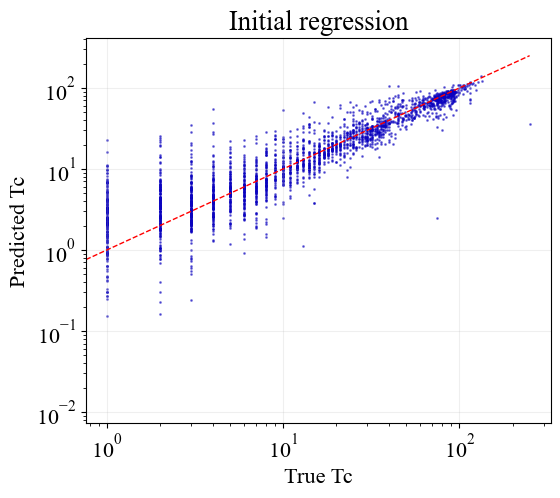

In [7]:
lgb_train = lgb.Dataset(Xr_train, Yr_train)
lgb_eval  = lgb.Dataset(Xr_test,  Yr_test, reference=lgb_train)

params = {
    'boosting_type': 'gbdt', 
    'objective': 'regression',  
    'num_leaves': 6,        
    'verbose': 1,           
}

# Train the model:
gbm = lgb.train(params,                             # General settings (defined above)
                lgb_train,                          # Data to use for training
                num_boost_round=1000,               # How many rounds for training
                valid_sets=lgb_eval,                # Data to use for validation
                callbacks=[early_stopping(20)])     # Stops if no improvement is seen in N=20 rounds.


y_pred = gbm.predict(Xr_test, num_iteration=gbm.best_iteration)  

# Evaluate initial model:
y_pred_val = gbm.predict(Xr_val, num_iteration=gbm.best_iteration)
mse  = mean_squared_error(Yr_val, y_pred_val)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(Yr_val, y_pred_val)
r2   = r2_score(Yr_val, y_pred_val)

print('Regression performance on validation set')
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

fig, ax = plt.subplots(1, figsize=(6, 5), dpi=100)
ax.scatter(Yr_val, y_pred_val, s=1, alpha=0.5)
ax.plot([Yr_val.min(), Yr_val.max()], [Yr_val.min(), Yr_val.max()], 'r--', lw=1)
ax.set_xlabel('True Tc')
ax.set_ylabel('Predicted Tc')
ax.set_title(f'Initial LGB  |  R² = {r2:.3f}')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_title('Initial regression')

plt.show()


## Feature importance

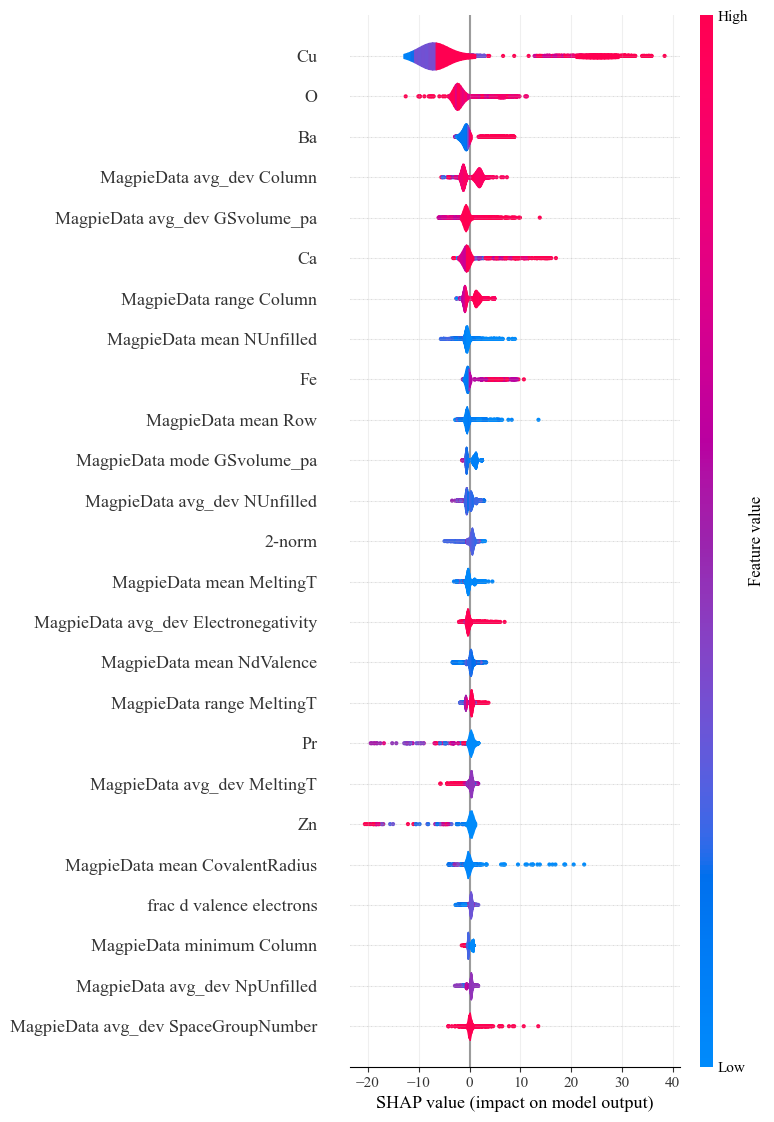

['Cu', 'O', 'Ba', 'MagpieData avg_dev Column', 'MagpieData avg_dev GSvolume_pa', 'Ca', 'MagpieData range Column', 'MagpieData mean NUnfilled', 'Fe', 'MagpieData mean Row', 'MagpieData mode GSvolume_pa', 'MagpieData avg_dev NUnfilled', '2-norm', 'MagpieData mean MeltingT', 'MagpieData avg_dev Electronegativity', 'MagpieData mean NdValence', 'MagpieData range MeltingT', 'Pr', 'MagpieData avg_dev MeltingT', 'Zn', 'MagpieData mean CovalentRadius', 'frac d valence electrons', 'MagpieData minimum Column', 'MagpieData avg_dev NpUnfilled', 'MagpieData avg_dev SpaceGroupNumber', 'MagpieData avg_dev NfUnfilled', 'MagpieData mean AtomicWeight', 'MagpieData maximum NfUnfilled', 'MagpieData mean Electronegativity', 'MagpieData mean NdUnfilled', 'MagpieData mean NValence', 'MagpieData avg_dev CovalentRadius', 'MagpieData mean GSmagmom', 'MagpieData mean NfValence', 'MagpieData minimum CovalentRadius', 'MagpieData maximum GSvolume_pa', 'MagpieData avg_dev NdValence', 'MagpieData avg_dev MendeleevNumb

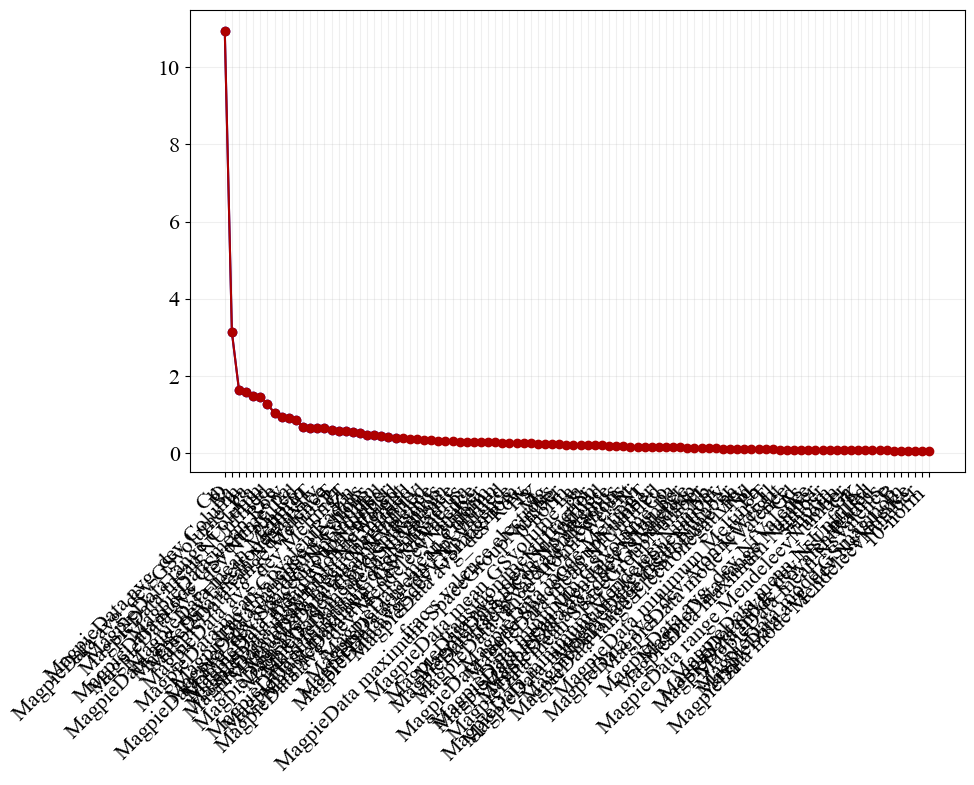

In [21]:
import shap

Xr_test_shap = Xr_test.copy()
bool_cols = Xr_test_shap.select_dtypes(include='bool').columns
Xr_test_shap[bool_cols] = Xr_test_shap[bool_cols].astype(int)

explainer = shap.TreeExplainer(gbm)
shap_values = explainer.shap_values(Xr_test_shap)

shap_importance = np.abs(shap_values).mean(axis=0)

shap.summary_plot(shap_values, Xr_test_shap,
                  feature_names=Xr_test_shap.columns,
                  plot_type="violin", max_display=25)

Xr_test_shap = Xr_test.select_dtypes(include='number').astype(float)


feature_importance_df = pd.DataFrame({
    'feature': Xr_train.columns, 
    'importance': shap_importance
}).sort_values('importance', ascending=False)

# Extract top 15
top_features = feature_importance_df.head(100)

# Get just the feature names as a list
feat_shap = top_features['feature'].tolist()
print(feat_shap)

plt.figure(figsize=(10,6))
plt.plot(feature_importance_df.head(25)['feature'].tolist(), feature_importance_df.head(25)['importance'], marker='o')
plt.plot(feat_shap, top_features['importance'], marker='o')
plt.xticks(rotation=45, ha='right')
plt.show()

In [20]:
from sklearn.metrics import root_mean_squared_error, r2_score
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0), 
    index=Xr_train.columns
)

results = {}
for n_feats in [10, 20, 30, 50, 70, 100, len(shap_values)]:
    top_feats = shap_importance.nlargest(n_feats).index.tolist()
    
    model = lgb.LGBMRegressor(**params)
    model.fit(Xr_train[top_feats], Yr_train,
              eval_set=[(Xr_test[top_feats], Yr_test)],
              eval_metric="rmse",
              callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)])
    
    y_pred = model.predict(Xr_test[top_feats])
    results[n_feats] = {
        'rmse': root_mean_squared_error(Yr_test, y_pred),
        'r2':   r2_score(Yr_test, y_pred)
    }

for n, metrics in results.items():
    print(f"  {n:>4} features — RMSE: {metrics['rmse']:.3f} K   R²: {metrics['r2']:.3f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000904 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1702
[LightGBM] [Info] Number of data points in the train set: 8196, number of used features: 10
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 23.810151
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 12.4759	valid_0's l2: 155.648
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001062 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, y

## Optimize

In [22]:
import optuna
import numpy as np
import lightgbm as lgb
from sklearn.metrics import root_mean_squared_error

def objective_shap(trial):
    Yr_train_log = np.log1p(Yr_train)
    Yr_test_log = np.log1p(Yr_test)

    lr = trial.suggest_float("learning_rate", 1e-4, 0.05, log=True)
    
    # Scale early stopping patience with learning rate
    patience = int(min(max(50, 0.1 / lr), 500))

    params = {
        "objective": "regression",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 42,
        "n_jobs": -1,
        "learning_rate":     lr,
        "num_leaves":        trial.suggest_int  ("num_leaves",        16,   256),
        "max_depth":         trial.suggest_int  ("max_depth",         3,    12),
        "min_child_samples": trial.suggest_int  ("min_child_samples", 5,    200),
        "subsample":         trial.suggest_float("subsample",         0.5,  1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree",  0.5,  1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha",         1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda",        1e-8, 10.0, log=True),
    }

    model = lgb.LGBMRegressor(**params, n_estimators=10000)
    model.fit(
        Xr_train[feat_shap],
        Yr_train_log,
        eval_set=[(Xr_test[feat_shap], Yr_test_log)],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(patience),
            lgb.log_evaluation(0),
        ],
    )

    y_pred = np.expm1(model.predict(Xr_test[feat_shap]))
    return root_mean_squared_error(Yr_test, y_pred)

study_shap = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=2,
    ),
)
study_shap.optimize(
    objective_shap,
    n_trials=500,
    show_progress_bar=True,
)

print("\nBest RMSE:", study_shap.best_value)
print("\nBest Parameters:")
for k, v in study_shap.best_params.items():
    print(f"  {k}: {v}")


[I 2026-05-28 12:38:59,926] A new study created in memory with name: no-name-caca7884-0896-420a-a181-979253604a50
  0%|          | 0/500 [00:00<?, ?it/s]

Training until validation scores don't improve for 97 rounds
Did not meet early stopping. Best iteration is:
[10000]	valid_0's rmse: 0.485714	valid_0's l2: 0.235918


Best trial: 0. Best value: 10.9371:   0%|          | 1/500 [01:57<16:19:02, 117.72s/it]

[I 2026-05-28 12:40:57,646] Trial 0 finished with value: 10.937065500208197 and parameters: {'learning_rate': 0.0010253509690168491, 'num_leaves': 245, 'max_depth': 10, 'min_child_samples': 122, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469887}. Best is trial 0 with value: 10.937065500208197.
Training until validation scores don't improve for 50 rounds


Best trial: 0. Best value: 10.9371:   0%|          | 2/500 [02:27<9:06:59, 65.90s/it]  

...

Best trial: 205. Best value: 9.24557:  83%|████████▎ | 414/500 [8:00:48<7:05:57, 297.18s/it]

[I 2026-05-28 20:39:48,415] Trial 413 finished with value: 9.48996439622166 and parameters: {'learning_rate': 0.004962791127327303, 'num_leaves': 237, 'max_depth': 8, 'min_child_samples': 9, 'subsample': 0.869510832647372, 'colsample_bytree': 0.9579070895117028, 'reg_alpha': 3.047147438963291e-08, 'reg_lambda': 3.832111525465703}. Best is trial 205 with value: 9.24556904235936.
Training until validation scores don't improve for 50 rounds


Best trial: 205. Best value: 9.24557:  83%|████████▎ | 414/500 [8:01:06<1:39:56, 69.73s/it] 

[W 2026-05-28 20:40:06,195] Trial 414 failed with parameters: {'learning_rate': 0.004205095366563194, 'num_leaves': 242, 'max_depth': 8, 'min_child_samples': 43, 'subsample': 0.8990494872649762, 'colsample_bytree': 0.9740962847098478, 'reg_alpha': 1.589254084215234e-08, 'reg_lambda': 2.298750919603017} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/4j/lbqb_ng55ysg6qxq228d19380000gn/T/ipykernel_23208/3425023327.py", line 32, in objective_shap
    model.fit(
  File "/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/lightgbm/sklearn.py", line 1398, in fit
    super().fit(
  File "/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/lightgbm/sklearn.py", line 1049, in fit
    self._Booster = train(
  File "/Users/fbnielsen/miniconda3/envs/tf/lib/

KeyboardInterrupt: 

## Plot result from HP opt

Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[343]	valid_0's l2: 0.714939
Regression performance on validation set
RMSE : 10.0682
MAE  : 4.7873
R²   : 0.7409


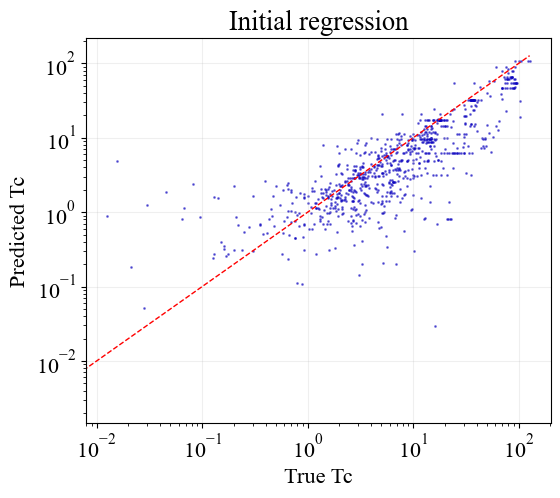

In [ ]:
Yr_train_log = np.log1p(Yr_train)
Yr_test_log = np.log1p(Yr_test)

lgb_train = lgb.Dataset(Xr_train[feat_shap], Yr_train_log)
lgb_eval  = lgb.Dataset(Xr_test[feat_shap],  Yr_test_log, reference=lgb_train)

params = study_shap.best_params

patience = int(min(max(50, 0.1 / params['learning_rate']), 500))

# Train the model:
gbm = lgb.train(params,                             # General settings (defined above)
                lgb_train,                          # Data to use for training
                num_boost_round=1000,               # How many rounds for training
                valid_sets=lgb_eval,                # Data to use for validation
                callbacks=[early_stopping(patience)])     # Stops if no improvement is seen in N=20 rounds.


y_pred = np.expm1(gbm.predict(Xr_test[feat_shap], num_iteration=gbm.best_iteration))

# Evaluate initial model:
y_pred_val = np.expm1(gbm.predict(Xr_val[feat_shap], num_iteration=gbm.best_iteration))
mse  = mean_squared_error(Yr_val, y_pred_val)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(Yr_val, y_pred_val)
r2   = r2_score(Yr_val, y_pred_val)

print('Regression performance on validation set')
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

fig, ax = plt.subplots(1, figsize=(6, 5), dpi=100)
ax.scatter(Yr_val, y_pred_val, s=1, alpha=0.5)
ax.plot([Yr_val.min(), Yr_val.max()], [Yr_val.min(), Yr_val.max()], 'r--', lw=1)
ax.set_xlabel('True Tc')
ax.set_ylabel('Predicted Tc')
ax.set_title(f'Initial LGB  |  R² = {r2:.3f}')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_title('Regression (optimized)')

plt.show()
